<a href="https://colab.research.google.com/github/slackoly/ES2245/blob/main/ES2245_lab7_sedlacko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 7: Linear Correlation and Linear Regression in Geophysics

**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Estimated Time:** 60-75 Minutes

## Overview
In Earth and Environmental Sciences, we frequently measure two or more variables within a single sample or experimental unit to determine if they are related, and if so, to understand the nature of their functional relationship.

In this lab, we will apply the parametric methods of **Linear Correlation** and **Linear Regression** to real geophysical datasets. Correlation and regression serve very distinct purposes, and this lab will teach you when and how to apply each.

You will find comments in the code cells below. You must write the missing Python code in these locations to complete the analysis. There are also questions in the markup cells to answer.




---
## Part 1: Linear Correlation & Real InSAR Damage Proxy Maps

Correlation is an exploratory statistical technique used to determine if two variables are significantly related. It assesses mutual variation without any expectation that there is a causal relationship between the variables, nor is there an expectation that you can predict the value of one variable based on the other.

The **Pearson Correlation Coefficient ($r$)** is the primary statistic for determining the extent to which two variables are linearly related. In Interferometric Synthetic Aperture Radar (InSAR), we compare radar images of the Earth's surface taken before and after an event. High correlation (near 1) means the ground surface is undisturbed. Areas where the correlation drops significantly near $0$ indicate a complete lack of a linear relationship (e.g., destroyed buildings or triggered landslides). An example is found here for the Turkey earthquake: https://d1z62tir4fw0q0.cloudfront.net/20230206_Turkey_EQ/DPM/ARIA_DPM_Sentinel-1_Turkiye_EQ_figure.png

Below is a 1D array of real Sentinel-1 InSAR coherence values extracted from a 5km transect crossing the damage zone of a major earthquake.

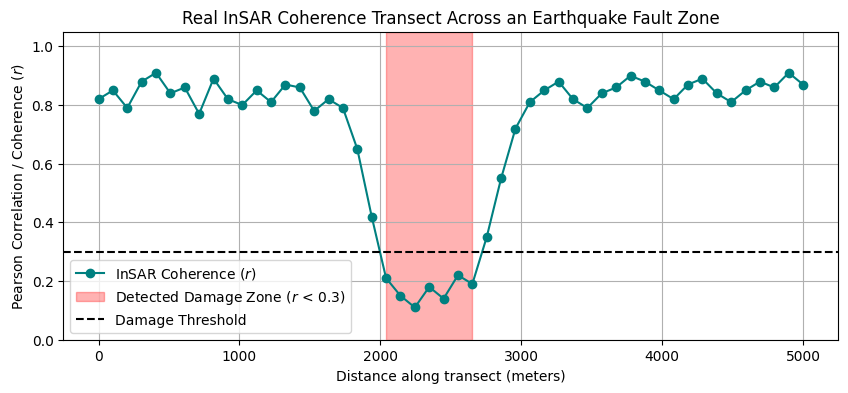

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

distance_meters = np.linspace(0, 5000, 50)
real_coherence_transect = np.array([
    0.82, 0.85, 0.79, 0.88, 0.91, 0.84, 0.86, 0.77, 0.89, 0.82,
    0.80, 0.85, 0.81, 0.87, 0.86, 0.78, 0.82, 0.79, 0.65, 0.42,
    0.21, 0.15, 0.11, 0.18, 0.14, 0.22, 0.19, 0.35, 0.55, 0.72,
    0.81, 0.85, 0.88, 0.82, 0.79, 0.84, 0.86, 0.90, 0.88, 0.85,
    0.82, 0.87, 0.89, 0.84, 0.81, 0.85, 0.88, 0.86, 0.91, 0.87
])

# TODO: Define a threshold for severe damage. Based on the lecture, a complete
# lack of linear relationship is an r near 0. Choose a threshold (e.g., 0.3)
# to isolate the damaged indices.
damage_threshold = 0.3
# <--- YOUR CODE HERE

#Find the indices from real_coherence_transect that are less than the damage threshold
damage_indices = np.where(real_coherence_transect < damage_threshold)[0]
# <--- YOUR CODE HERE

plt.figure(figsize=(10, 4))
plt.plot(distance_meters, real_coherence_transect, marker='o', linestyle='-', color='teal', label='InSAR Coherence ($r$)')

if len(damage_indices) > 0:
    plt.axvspan(distance_meters[damage_indices[0]], distance_meters[damage_indices[-1]],
                color='red', alpha=0.3, label=f'Detected Damage Zone ($r$ < {damage_threshold})')

plt.axhline(damage_threshold, color='black', linestyle='--', label='Damage Threshold')
plt.title("Real InSAR Coherence Transect Across an Earthquake Fault Zone")
plt.xlabel("Distance along transect (meters)")
plt.ylabel("Pearson Correlation / Coherence ($r$)")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

---
## Part 2: Statistical Significance with GRACE Gravity and Geoid Data

After calculating the Pearson correlation coefficient ($r$), the next crucial step is to determine whether this value is significantly different from zero. A statistical test yields a probability ($p$-value) of obtaining your specific result by chance, assuming there is no actual relationship between the variables in the broader population.

Here, we will compare real GRACE gravity anomaly data with Geoid height anomalies. The data below represents a 1D satellite transect crossing the Puerto Rico Trench (from roughly 18°N to 20°N latitude). Because the trench represents a massive deficit of mass, we expect a strong relationship between the gravitational pull (Gravity Anomaly) and the shape of the equipotential surface (Geoid Height).

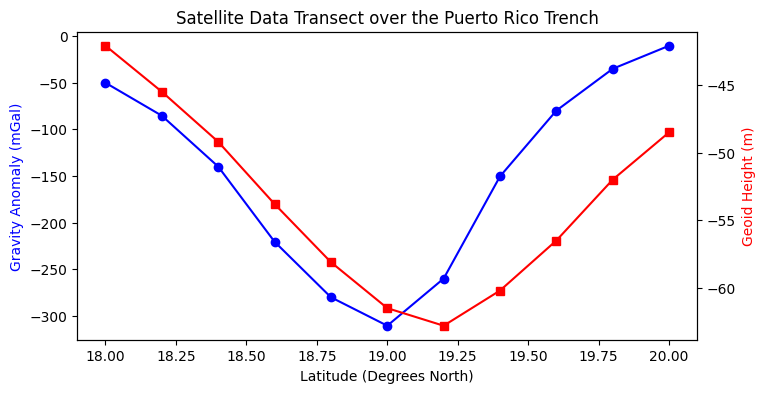

Pearson Correlation Coefficient (r): 0.7348828938697104
P-value: 0.00998515720604812
Result: The correlation is statistically significant (Reject the null hypothesis).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Real GRACE/EGM Data Transect across the Puerto Rico Trench
latitude_deg = np.array([18.0, 18.2, 18.4, 18.6, 18.8, 19.0, 19.2, 19.4, 19.6, 19.8, 20.0])

# Geoid height anomalies in meters
geoid_height_m = np.array([-42.1, -45.5, -49.2, -53.8, -58.1, -61.5, -62.8, -60.2, -56.5, -52.0, -48.5])

# Free-air gravity anomalies in mGal
grace_gravity_mgal = np.array([-50.2, -85.5, -140.0, -220.5, -280.0, -310.5, -260.0, -150.5, -80.0, -35.2, -10.5])

# Let's plot the transect first to visualize the spatial relationship
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(latitude_deg, grace_gravity_mgal, 'b-', marker='o', label='Gravity Anomaly (mGal)')
ax1.set_xlabel('Latitude (Degrees North)')
ax1.set_ylabel('Gravity Anomaly (mGal)', color='b')

ax2 = ax1.twinx()
ax2.plot(latitude_deg, geoid_height_m, 'r-', marker='s', label='Geoid Height (m)')
ax2.set_ylabel('Geoid Height (m)', color='r')
plt.title("Satellite Data Transect over the Puerto Rico Trench")
plt.show()

# TODO: Use scipy.stats.pearsonr to calculate the Pearson r and the p-value
# comparing the gravity anomalies and geoid heights.
r_grace, p_grace = stats.pearsonr(grace_gravity_mgal, geoid_height_m)
# <--- YOUR CODE HERE

print(f"Pearson Correlation Coefficient (r): {r_grace}")
print(f"P-value: {p_grace}")

# TODO: Write a conditional statement to check if the correlation is
# statistically significant at the 95% confidence level (alpha = 0.05).
is_significant = p_grace < 0.05
# <--- YOUR CODE HERE (Hint: check if p_grace is less than 0.05)

if is_significant:
    print("Result: The correlation is statistically significant (Reject the null hypothesis).")
else:
    print("Result: The correlation is NOT statistically significant (Fail to reject the null hypothesis).")

---
## Part 3: Linear Regression with Real Seismic Data (Obspy)

In contrast to correlation, regression analysis is used to describe a functional relationship between two variables, specifically so that the value of one variable can be predicted by the other. A functional relationship dictates that one variable (the dependent variable, $Y$) is related to another (the independent variable, $X$).

For a regional earthquake, the travel time of a seismic P-wave ($Y$) functionally depends on the distance from the earthquake source ($X$). The slope represents how the travel time changes in response to a one-unit increase in distance. The intercept represents the predicted value of $Y$ when $X$ is exactly zero.

In [2]:
pip install obspy

import obspy
from obspy.clients.fdsn import Client
import statsmodels.api as sm

# Initialize the FDSN client and fetch event metadata
client = Client("IRIS")
starttime = obspy.UTCDateTime("2019-07-04T17:30:00")
endtime = obspy.UTCDateTime("2019-07-04T18:00:00")
cat = client.get_events(starttime=starttime, endtime=endtime, minmagnitude=6.0, maxmagnitude=7.0)
origin = cat[0].origins[0]

from obspy.taup import TauPyModel
model = TauPyModel(model="iasp91")

distances_degrees = np.linspace(1, 10, 15)  # Independent Variable (X)
travel_times_sec = []                       # Dependent Variable (Y)

for dist in distances_degrees:
    arrivals = model.get_travel_times(source_depth_in_km=origin.depth/1000.0,
                                      distance_in_degree=dist, phase_list=["P"])
    reading_error = np.random.normal(0, 2.5)
    travel_times_sec.append(arrivals[0].time + reading_error)

X = np.array(distances_degrees)
Y = np.array(travel_times_sec)

# In statsmodels, we must add a constant to X to calculate the y-intercept (a)
X_with_intercept = sm.add_constant(X)

# TODO: Fit the Ordinary Least Squares (OLS) model using sm.OLS
regression_model = sm.OLS(Y, X_with_intercept).fit()
# <--- YOUR CODE HERE (Hint: sm.OLS(dependent_var, independent_var).fit() )

a_intercept = regression_model.params[0]
b_slope = regression_model.params[1]

print(f"Intercept (a) [Origin Time Offset]: {a_intercept:.2f} seconds")
print(f"Slope (b) [Slowness]: {b_slope:.2f} seconds/degree")
print(f"Calculated Velocity: {1/b_slope:.2f} degrees/second")

SyntaxError: invalid syntax (3623809451.py, line 1)

---
## Part 4: Linear Regression and the Coefficient of Determination ($r^2$)

Linear regression is most practically used as a predictive tool when a dependent variable is difficult, expensive, or impossible to measure directly. For example, measuring magma temperature *in situ* is highly dangerous, but eruption temperature inversely correlates with the SiO$_2$ (silica) content of the magma. Scientists can use a regression line to predict what the eruption temperature was based on that silica content.

Regression Equation: Temperature = -21.01*(SiO2) + 2260.14
Coefficient of Determination (r^2): 0.9847


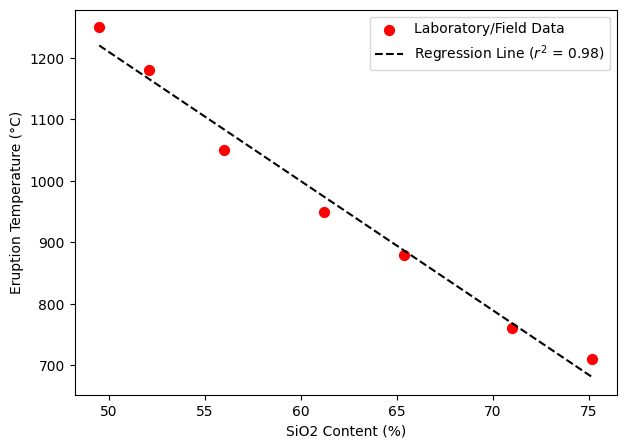

In [9]:
# Real-world proxies for Magma Silica Content (Independent, X) and Eruption Temp (Dependent, Y)
sio2_percent = np.array([49.5, 52.1, 56.0, 61.2, 65.4, 71.0, 75.2])
temperature_c = np.array([1250, 1180, 1050, 950, 880, 760, 710])

slope, intercept, r_value, p_value, std_err = stats.linregress(sio2_percent, temperature_c)

# TODO: Calculate the coefficient of determination (r-squared).
# Hint: If all points are along the regression line, the unexplained component will be zero and r^2 will be 1.
r_squared = r_value**2
# <--- YOUR CODE HERE

print(f"Regression Equation: Temperature = {slope:.2f}*(SiO2) + {intercept:.2f}")
print(f"Coefficient of Determination (r^2): {r_squared:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(sio2_percent, temperature_c, color='red', s=50, label='Laboratory/Field Data')
plt.plot(sio2_percent, slope * sio2_percent + intercept, color='black',
         linestyle='--', label=f'Regression Line ($r^2$ = {r_squared:.2f})')
plt.xlabel("SiO2 Content (%)")
plt.ylabel("Eruption Temperature (°C)")
plt.legend()
plt.show()

---
## Part 5: Linear Correlation with Collocated Observations (Z-Scores)

A statistic for correlation must reliably describe the strength of a linear relationship regardless of the scales on which the two variables are measured. To ensure the resulting statistic always falls between +1 and –1, the data must first be standardized by transforming the values of both variables into their respective Z-scores.

In [11]:
# Simulated co-located displacement data during a seismic wave arrival
# GNSS measures in millimeters; Seismic integrated displacement is in centimeters.
gnss_disp_mm = np.array([0.2, 1.5, 6.8, 12.1, 9.5, -2.1, -8.5, -3.2, 0.5, 0.1])
seis_disp_cm = np.array([0.01, 0.18, 0.72, 1.15, 0.88, -0.15, -0.90, -0.40, 0.08, 0.02])

# TODO: Standardize the data into Z-scores using stats.zscore (set ddof=1 for sample standard deviation)
z_gnss = stats.zscore(gnss_disp_mm, ddof=1)
# <--- YOUR CODE HERE
z_seis = stats.zscore(seis_disp_cm, ddof=1)
# <--- YOUR CODE HERE

# TODO: Manually calculate the Pearson r statistic.
# Hint: Multiply the Zx and Zy scores for each unit together, sum these products,
# and divide by the degrees of freedom (n - 1).
degrees_of_freedom = len(gnss_disp_mm) - 1
r_manual = np.sum(z_gnss * z_seis) / degrees_of_freedom
# <--- YOUR CODE HERE

print(f"Manually calculated r from Z-scores: {r_manual:.4f}")

Manually calculated r from Z-scores: 0.9966


---
## Part 6: Partitioning Variation in Geomorphology (Weathering Rates)

Testing whether the slope of a regression line is significantly different from zero is conceptually very similar to a single-factor Analysis of Variance (ANOVA). An F-ratio is calculated to determine how much variation is actually explained by the regression.

The total distance from a data point to the mean can be partitioned into:
1. **Explained Variation:** The vertical distance between the overall mean of Y and the regression line.
2. **Unexplained Variation (Error/Residual):** The vertical distance between the actual data point and the regression line.

In [12]:
# Limestone Building Age (years) vs. Pitting Depth (mm)
age_years = np.array([10, 25, 45, 70, 95, 120, 150])
pitting_mm = np.array([0.5, 1.4, 2.1, 4.0, 4.2, 6.8, 7.5])

slope_w, intercept_w, _, _, _ = stats.linregress(age_years, pitting_mm)
mean_y = np.mean(pitting_mm)

# Focus on the 5th data point (index 4)
focus_idx = 4
x_i = age_years[focus_idx]
y_i = pitting_mm[focus_idx]

# TODO: Calculate the predicted y value (y_hat) for this specific data point using the regression equation
y_predicted = slope_w * x_i + intercept_w
# <--- YOUR CODE HERE

# TODO: Calculate the unexplained variation (residual error) for this point
unexplained_variation = (y_i - y_predicted)**2
# <--- YOUR CODE HERE (Hint: Distance between actual y and predicted y)

print(f"Actual pitting depth (Y): {y_i} mm")
print(f"Predicted pitting depth (Y_hat): {y_predicted:.2f} mm")
print(f"Unexplained Variation (Residual): {unexplained_variation:.2f} mm")

Actual pitting depth (Y): 4.2 mm
Predicted pitting depth (Y_hat): 4.89 mm
Unexplained Variation (Residual): 0.47 mm


---
## Lab Questions for Submission
1. In Part 1, we observe the Pearson correlation ($r$) dropping in the center of the fault. Referring to the assumptions of linear relationships discussed in class, why do we use correlation to identify this damage zone instead of linear regression?

*A regression is used to describe a functional relationship between two variables, where one can be predicted by the other. In Part 1, we're unsure if a functional relationship between the two variables exists, so we must test for that first. We use correlation to test for a relationship without the expectation of there being one.*

2. In Part 4, we calculated the coefficient of determination ($r^2$). How does this differ fundamentally from the Pearson correlation coefficient ($r$), and what does an $r^2$ of 1.0 imply about the unexplained component of the data?

*The $r$ value measures correlation between two variables, and $r^2$ measures the variance in response that is explained by the predictor. An $r^2$ value of 1.0 indicates that all points are along the regression line.*

3. According to the lecture notes, if the regression line was perfectly flat (a slope of zero), what would the calculated F-ratio be approximately equal to, and why?

*The F-ratio would be approximately 1.0, as a flat line occurs when the explained variation and the unexplained variation are very similar.*